# Imports

In [ ]:
!pip install scanpy
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

file_path = "/content/drive/MyDrive/GP_datasets/Pancreas/Baron_Pancreas_Human_mix.h5ad"
adata = sc.read_h5ad(file_path)

print(adata)


AnnData object with n_obs × n_vars = 8569 × 16381
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'


In [ ]:
#drop other class
# adata = adata[adata.obs["cell_type"] != "Other"].copy()
# print(adata.obs["cell_type"].value_counts())
labels = adata.obs["cell_type"]
X = adata.X
print("Number of classes:", labels.nunique())

Number of classes: 14


In [ ]:
labels.unique()

['acinar', 'beta', 'delta', 'activated_stellate', 'ductal', ..., 'quiescent_stellate', 'macrophage', 'schwann', 'mast', 't_cell']
Length: 14
Categories (14, object): ['acinar', 'activated_stellate', 'alpha', 'beta', ..., 'mast',
                          'quiescent_stellate', 'schwann', 't_cell']

## Normalization

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## Select HVG

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor='seurat')
adata


AnnData object with n_obs × n_vars = 8569 × 2000
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [ ]:
adata.var.head()


,highly_variable,means,dispersions,dispersions_norm
A2M,True,0.126910,1.970163,1.375732
A4GALT,True,0.165554,1.632704,0.667794
AADAC,True,0.168547,1.898773,1.225967
ABCB11,True,0.001296,1.767330,0.950219
ABCC8,True,1.571017,3.055320,1.809396


## PCA

In [ ]:
sc.tl.pca(adata, n_comps=50)
adata

AnnData object with n_obs × n_vars = 8569 × 2000
    obs: 'donor_id', 'cell_type', 'barcode', 'donor_batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [ ]:

y = labels.values

## Models



In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

clf = LogisticRegression(max_iter=300, multi_class='multinomial', solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = adata.X
y = adata.obs["cell_type"]

# logistic regression
y_pred_lr = cross_val_predict(clf, X, y, cv=kf)

# knn
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

y_pred_knn = cross_val_predict(knn, X, y, cv=kf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

### Evaluation

=== Logistic Regression ===
Accuracy: 0.9889135254988913
                    precision    recall  f1-score   support

            acinar       0.99      0.99      0.99       958
activated_stellate       0.98      0.98      0.98       284
             alpha       1.00      1.00      1.00      2326
              beta       0.99      0.99      0.99      2525
             delta       0.97      0.98      0.97       601
            ductal       0.99      0.99      0.99      1077
       endothelial       1.00      0.99      1.00       252
           epsilon       0.94      0.83      0.88        18
             gamma       0.98      0.99      0.99       255
        macrophage       0.98      1.00      0.99        55
              mast       1.00      1.00      1.00        25
quiescent_stellate       0.95      0.95      0.95       173
           schwann       1.00      1.00      1.00        13
            t_cell       1.00      1.00      1.00         7

          accuracy                       

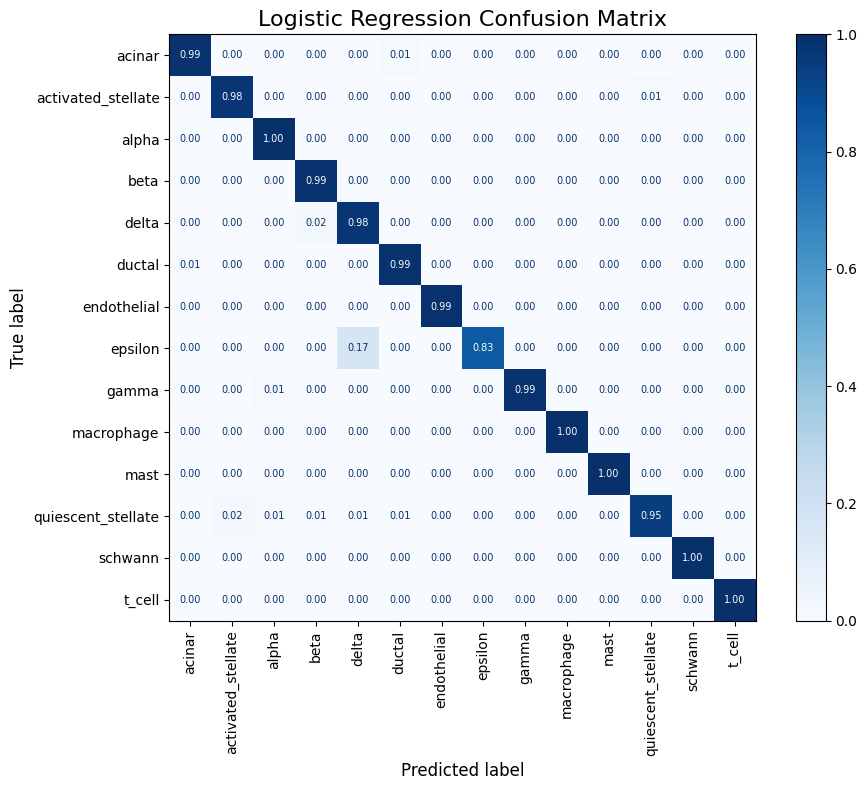


=== k-NN ===
Accuracy: 0.9821449410666355
                    precision    recall  f1-score   support

            acinar       0.97      0.99      0.98       958
activated_stellate       0.92      0.98      0.95       284
             alpha       0.99      1.00      0.99      2326
              beta       0.98      0.99      0.99      2525
             delta       0.98      0.94      0.96       601
            ductal       0.99      0.98      0.98      1077
       endothelial       1.00      0.96      0.98       252
           epsilon       0.94      0.83      0.88        18
             gamma       0.98      0.99      0.98       255
        macrophage       0.98      1.00      0.99        55
              mast       1.00      1.00      1.00        25
quiescent_stellate       0.97      0.84      0.90       173
           schwann       1.00      0.85      0.92        13
            t_cell       1.00      0.71      0.83         7

          accuracy                           0.98      

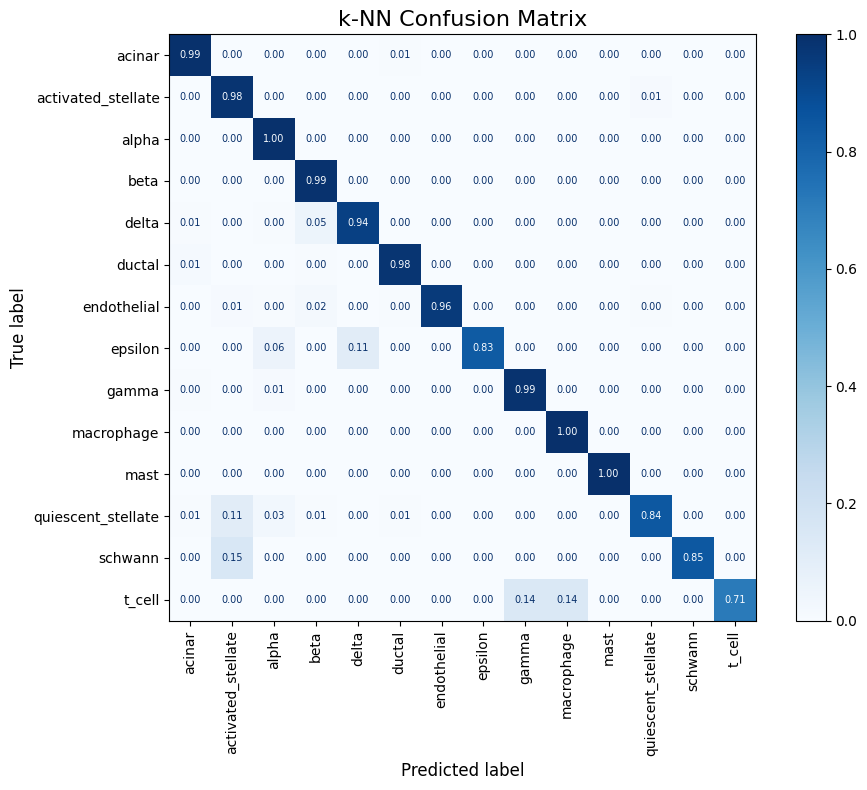

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y, y_pred_lr))
print(classification_report(y, y_pred_lr))
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")

print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y, y_pred_knn))
print(classification_report(y, y_pred_knn))
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

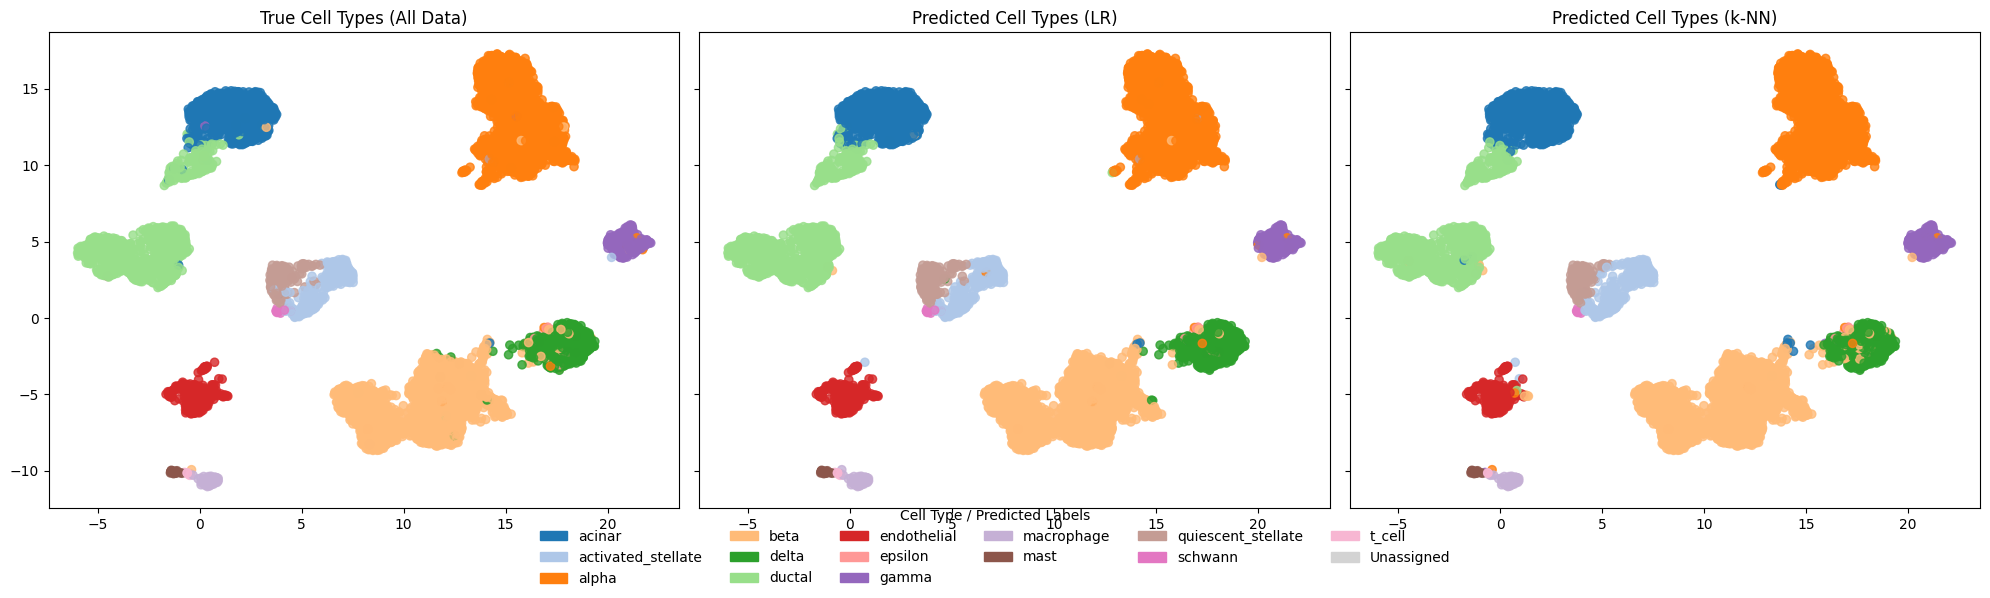

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from matplotlib.patches import Patch

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# Compute UMAP (once)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

# Combine all labels
all_labels = np.unique(np.concatenate([
    adata.obs["cell_type"].to_numpy(),
    adata.obs['y_pred_lr'].to_numpy(),
    adata.obs['y_pred_knn'].to_numpy()
]))

# Create consistent color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['cell_type'].map(label_to_color)
adata.obs['color_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_knn'] = adata.obs['y_pred_knn'].map(label_to_color)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
